In [1]:
#!pip install xgboost
#!pip install optuna
#!pip install plotly
#!pip install shap
#!pip install numpy==2.2 (porque lo pide shap, con la version 2.3 de numpy no funciona)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, fbeta_score, roc_curve, roc_auc_score
from xgboost import XGBClassifier
import optuna
import shap

## 1) Carga de datos
La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [2]:
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/refs/heads/master/Pr%C3%A1ctico/diabetes_prediction_dataset_train-labeled.csv")


## 2) Grilla informativa de las variables:

Paciente: Nro identificador del paciente

Gender: Sexo del paciente

Age: Edad del paciente

Hypertension: Var. categórica que indica si el paciente tiene hipertensión o no

Heart_disease: Var. categórica que indica si el paciente tiene enfermades del corazón o no

Smoking_history: Var. categórica que indica el historial de fumador del paciente.

Bmi: Indice de masa corporal del paciente, se puede acomodar de la siguiente manera:
- Menor a 18.5 = bajo peso
- Entre 18.5 y 24.9 = peso normal
- Entre 25 y 29.9 = sobrepeso
- Mayor a 30 = obesidad

HbA1c_level: Hemoglobina Glicosilada, mide el nivel promedio de glucosa o azúcar en la sangre durante los últimos tres meses, es un porcentaje y se puede ordenar:
- Menor a 5.7% = normal
- Entre 5.7% y 6.4% = prediabetes
- Mayor a 6.5% = diabetes diagnosticada

Blood_glucose_level: Medición de glucosa en sangre en un momento puntual, se mide en mg/dl y se puede acomodar de la siguiente manera:
- Menor a 100 = normal
- Entre 100 y 125 = prediabetes
- Mayor a 126 = diabetes

## 3) Analísis exploratorio y curación de los datos

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


In [4]:
dataset.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0


In [5]:
dataset.describe()

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,50016.501389,41.935269,0.075074,0.039463,27.320879,5.527659,138.070537,0.085074
std,28868.357071,22.514788,0.263512,0.194695,6.626335,1.070261,40.739962,0.278993
min,1.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,25021.750000,24.000000,0.000000,0.000000,23.650000,4.800000,100.000000,0.000000
50%,50024.000000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,75024.250000,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,100000.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


En esta salida de algunas métricas estadísticas se puede observar que el rango etario del dataset es de los 0,08 años hasta los 80 años, el mínimo podría ser un error o realmente ser pacientes de dicha edad.

In [6]:
test_df = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/refs/heads/master/Pr%C3%A1ctico/diabetes_prediction_dataset_test.csv")
print(test_df.shape)
print(test_df.describe())

(5000, 10)
            patient          age  hypertension  heart_disease          bmi  \
count   5000.000000  5000.000000   5000.000000    5000.000000  5000.000000   
mean   49696.473600    40.947016      0.070600       0.038600    27.318644   
std    28855.568156    22.537466      0.256181       0.192659     6.832943   
min        7.000000     0.160000      0.000000       0.000000    10.620000   
25%    24720.750000    23.000000      0.000000       0.000000    23.410000   
50%    49522.500000    41.000000      0.000000       0.000000    27.320000   
75%    74686.000000    59.000000      0.000000       0.000000    29.632500   
max    99970.000000    80.000000      1.000000       1.000000    88.760000   

       HbA1c_level  blood_glucose_level  diabetes  
count  5000.000000          5000.000000       0.0  
mean      5.524620           137.821000       NaN  
std       1.078559            40.101933       NaN  
min       3.500000            80.000000       NaN  
25%       4.800000        

In [7]:
#Dataset con el que se evaluará el modelo
test_df.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN


In [8]:
dataset.sort_values('age', ascending=True).head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
27449,38884,Male,0.08,0,0,No Info,14.92,3.5,90,0
53274,3743,Male,0.08,0,0,No Info,12.80,6.6,80,0
8370,34664,Male,0.08,0,0,No Info,27.32,5.8,155,0
20999,53736,Male,0.08,0,0,No Info,12.08,6.2,158,0
82527,98966,Female,0.08,0,0,No Info,12.50,4.5,155,0


In [9]:
print('Tabla de valores únicos y su conteo de la variable Historial fumador')
print('--------------------------------------------------------------------')
dataset.value_counts('smoking_history')

Tabla de valores únicos y su conteo de la variable Historial fumador
--------------------------------------------------------------------


smoking_history
No Info        33958
never          33389
former          8911
current         8821
not current     6129
ever            3792
Name: count, dtype: int64

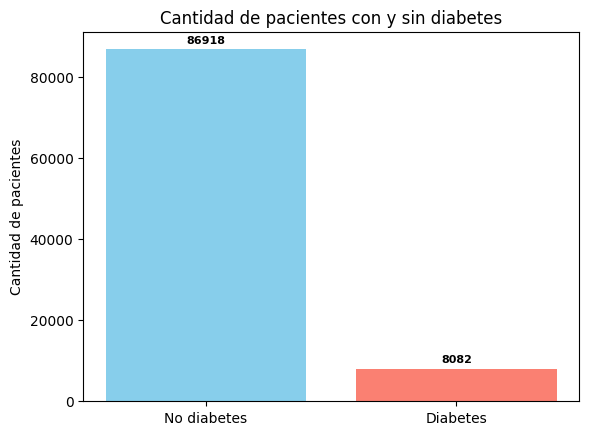

In [10]:
# Contar la cantidad de pacientes por clase
conteo = dataset['diabetes'].value_counts().sort_index()

# Crear el gráfico de barras
fig, ax = plt.subplots()
bars = ax.bar(['No diabetes', 'Diabetes'], conteo.values, color=['skyblue', 'salmon'])

# Agregar los números arriba de cada barra
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Cantidad de pacientes')
ax.set_title('Cantidad de pacientes con y sin diabetes')
plt.show()

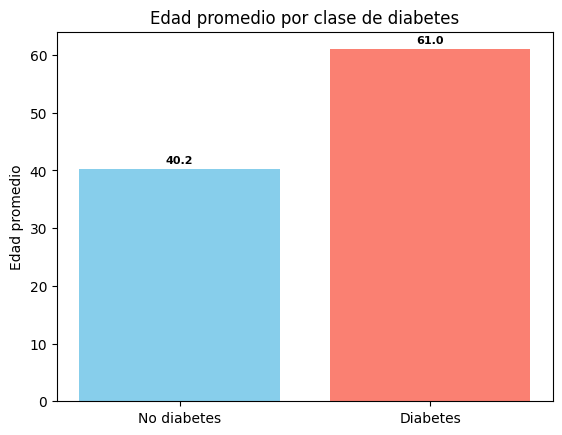

In [11]:
# Calcular la edad promedio para cada clase de diabetes
age_means = dataset.groupby('diabetes')['age'].mean()

# Crear el gráfico de barras
fig, ax = plt.subplots()
bars = ax.bar(['No diabetes', 'Diabetes'], age_means.values, color=['skyblue', 'salmon'])

# Agregar los valores arriba de cada barra
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Edad promedio')
ax.set_title('Edad promedio por clase de diabetes')
plt.show()

In [12]:
#Pacientes con hipertensión
dataset.value_counts('hypertension')

hypertension
0    87868
1     7132
Name: count, dtype: int64

In [13]:
#Pacientes con enfermedad cardíaca
dataset.value_counts('heart_disease')

heart_disease
0    91251
1     3749
Name: count, dtype: int64

En primer lugar, se analizó la distribución de la variable objetivo **diabetes**. El gráfico de barras muestra un fuerte desbalance: de un total de 95.000 registros, 86.918 pacientes no presentan diabetes frente a 8.082 pacientes que sí la presentan. Esto significa que la proporción de casos positivos es de apenas ~8,5%, lo cual debe tenerse en cuenta al momento de entrenar modelos, ya que un clasificador podría sesgarse hacia la clase mayoritaria si no se aplican técnicas de balanceo o métricas adecuadas.

Luego, se calculó y graficó la **edad promedio** en cada clase. Se observa que las personas con diabetes tienen una media de edad de **61 años**, mientras que el grupo sin diabetes presenta un promedio de **40,2 años**. Esto sugiere que la probabilidad de desarrollar diabetes aumenta con la edad, lo que coincide con el conocimiento médico existente.

En cuanto a las variables **hipertensión y enfermedad cardíaca**, ambas también presentan un marcado desbalance:

*   Hipertensión: 87.868 pacientes sin hipertensión frente a 7.132 con hipertensión
*   Enfermedad cardíaca: 91.251 pacientes sin enfermedad cardíaca frente a 3.749 con este antecedente.

Este comportamiento indica que, al igual que con la variable objetivo, la gran mayoría de los registros pertenecen a la clase negativa. Sin embargo, al observar posteriormente las probabilidades condicionales (que se calcularán más adelante), se podrá evaluar si estos factores, aunque poco frecuentes, representan un riesgo significativamente mayor de diabetes en los pacientes que los presentan.

In [14]:
#Probabilidades condicionales para variables categóricas respecto a diabetes

cat_vars = ['gender', 'hypertension', 'heart_disease', 'smoking_history']

for var in cat_vars:
    print(f"\nProbabilidad de diabetes dado {var}:")
    prob = dataset.groupby(var)['diabetes'].mean()
    print(prob)


Probabilidad de diabetes dado gender:
gender
Female    0.076184
Male      0.097638
Other     0.000000
Name: diabetes, dtype: float64

Probabilidad de diabetes dado hypertension:
hypertension
0    0.069400
1    0.278183
Name: diabetes, dtype: float64

Probabilidad de diabetes dado heart_disease:
heart_disease
0    0.075320
1    0.322486
Name: diabetes, dtype: float64

Probabilidad de diabetes dado smoking_history:
smoking_history
No Info        0.040845
current        0.101916
ever           0.116825
former         0.170912
never          0.095211
not current    0.106216
Name: diabetes, dtype: float64


En este primer calculo de probabilidades se puede observar las probabilidades condicionales de tener diabetes dado las variables.

 - Sobre la variable 'gender', el sexo masculino tiene una mayor probabilidad de tener diabetes que el sexo femenino, siendo la misma del casi del 10%-
 - En la variable 'hypertension' se observa una mayor probabilidad de contraer diabetes en aquellas personas que tengan problemas de hipertensión, la misma es del 27%.
 - En la variable 'heart_disease' tambien se observa una mayor probabilidad de tener diabetes en aquellas personas que sufran de problemas cardíacos, la misma es del 32%.
 - En la variable 'smoking_history' las probabalidades de contraer diabetes dado el historial fumador de la personas no difieren mucho entre si, se destaca que la categoría former presenta una mayor probabilidad de tener diabetes, siendo la misma del 17%.

In [15]:
# 1. Copiar el dataset original
cat_analisis = dataset.copy()

# 2. Categorizar BMI (Body Mass Index)
cat_analisis['bmi_cat'] = pd.cut(
    cat_analisis['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
)

# 3. Categorizar HbA1c_level (Hemoglobina Glicosilada)
cat_analisis['HbA1c_cat'] = pd.cut(
    cat_analisis['HbA1c_level'],
    bins=[0, 5.7, 6.5, float('inf')],
    labels=['Normal', 'Alto', 'Muy alto']
)

# 4. Categorizar blood_glucose_level
cat_analisis['glucosa_cat'] = pd.cut(
    cat_analisis['blood_glucose_level'],
    bins=[0, 100, 126, float('inf')],
    labels=['Normal', 'Alto', 'Muy alto']
)

# Lista de columnas que quiero ver
cols_vista = ['bmi', 'HbA1c_level', 'blood_glucose_level',
              'bmi_cat', 'HbA1c_cat', 'glucosa_cat']

# Mostrar solo esas columnas
cat_analisis[cols_vista].sample(10, random_state=42)

,bmi,HbA1c_level,blood_glucose_level,bmi_cat,HbA1c_cat,glucosa_cat
43450,25.47,4.8,126,Sobrepeso,Normal,Alto
14791,25.36,8.2,130,Sobrepeso,Muy alto,Muy alto
28617,36.19,5.7,90,Obesidad,Normal,Normal
60875,31.22,5.8,240,Obesidad,Alto,Muy alto
50419,30.13,6.5,126,Obesidad,Alto,Alto
79901,13.94,4.0,155,Bajo peso,Normal,Muy alto
91111,19.15,4.5,100,Normal,Normal,Normal
34188,36.73,8.2,220,Obesidad,Muy alto,Muy alto
18106,36.04,4.5,126,Obesidad,Normal,Alto
56770,26.35,5.7,155,Sobrepeso,Normal,Muy alto


In [16]:
#Probabilidades condicionales para variables categóricas respecto a diabetes

cat_vars = ['bmi_cat', 'HbA1c_cat', 'glucosa_cat']

for var in cat_vars:
    print(f"\nProbabilidad de diabetes dado {var}:")
    prob = cat_analisis.groupby(var)['diabetes'].mean()
    print(prob)


Probabilidad de diabetes dado bmi_cat:
bmi_cat
Bajo peso    0.007527
Normal       0.038733
Sobrepeso    0.073295
Obesidad     0.180130
Name: diabetes, dtype: float64

Probabilidad de diabetes dado HbA1c_cat:
HbA1c_cat
Normal      0.015248
Alto        0.077999
Muy alto    0.368198
Name: diabetes, dtype: float64

Probabilidad de diabetes dado glucosa_cat:
glucosa_cat
Normal      0.000000
Alto        0.082615
Muy alto    0.122721
Name: diabetes, dtype: float64


C:\Users\Damaso Solinas\AppData\Local\Temp\ipykernel_5640\3815109725.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob = cat_analisis.groupby(var)['diabetes'].mean()


En este último cálculo de probabilidades, una vez categorizadas las variables continuas y discretas del dataset se obtiene lo siguiente:
 - Un mayor índice de masa corporal lo que indica las categorías ascendentes para agrupar a la misma, presentan una mayor probabilidad de contraer diabetes.
 - El mismo caso es para hemogoblina glicosilada, a mayor porcentaje de la misma, mayor probabilidad de contraer diabetes.
 - Finalmente ocurre lo mismo para el nivel de glucosa en sangre, presenta mayores probabilidades de contraer diabetes a medida de mayor concentración de glucosa en sangre en las personas.

In [17]:

dataset[(dataset['blood_glucose_level'] < 100) & (dataset['diabetes'] == 1)]

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


No existe una observación con blood_glucose_level < 100 y diabetes = 1
- Esto significa que no hay pacientes con diabetes que tengan un nivel de glucosa en sangre por debajo de 100 mg/dL.

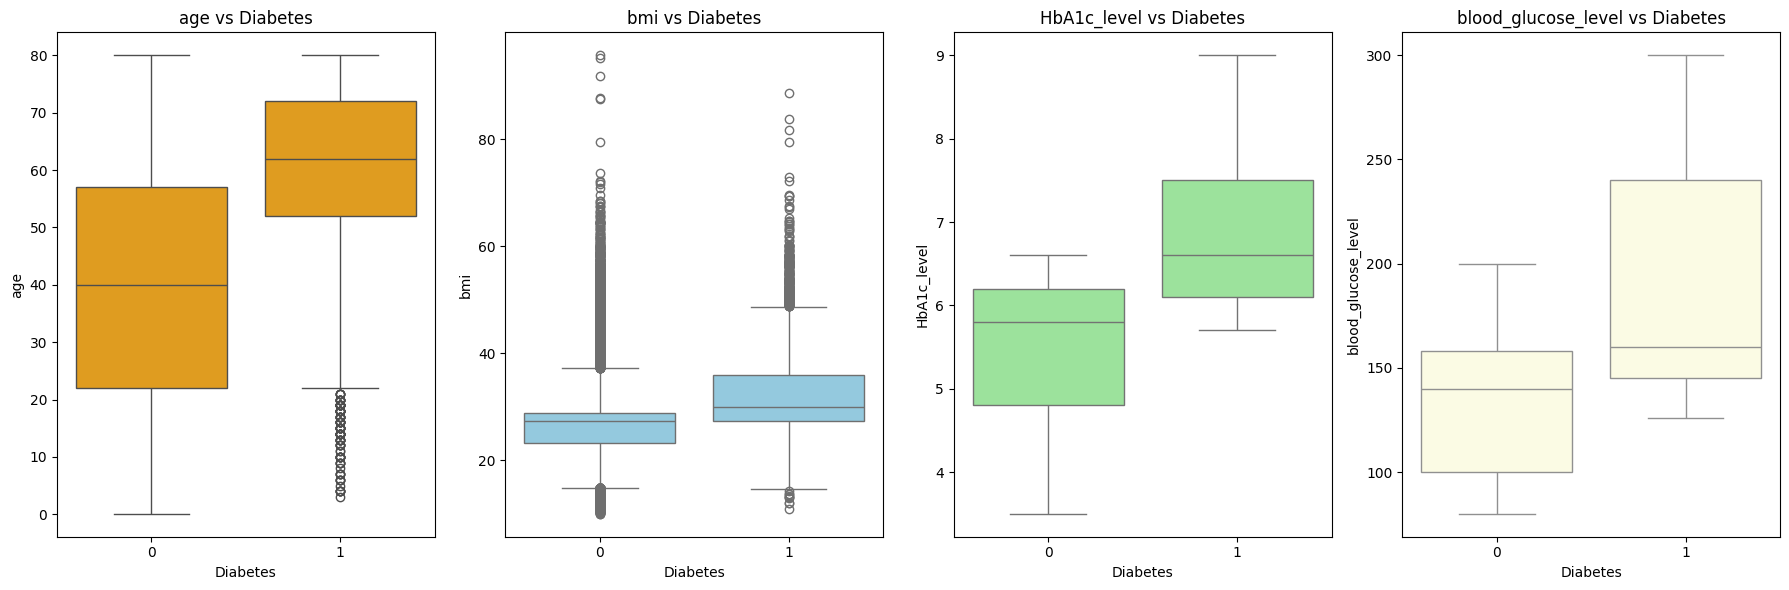

In [18]:
# Definir variables y colores
variables = ['age','bmi', 'HbA1c_level', 'blood_glucose_level']
colores = ['orange','skyblue', 'lightgreen', 'lightyellow']

# Crear la grilla de subplots
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Recorrer variables y crear cada boxplot
for i, var in enumerate(variables):
    sns.boxplot(data=cat_analisis, x='diabetes', y=var, ax=axes[i], color=colores[i])
    axes[i].set_title(f'{var} vs Diabetes')
    axes[i].set_xlabel('Diabetes')
    axes[i].set_ylabel(var)

# Ajustar layout
plt.tight_layout()
plt.show()

Podemos observar que:

*   **Age (edad)**: Como ya se había observado y mencionado anteriormente, los pacientes que presentan diabetes tienden a ser de mayor edad.

*   **Índice de Masa Corporal (BMI)**: los pacientes con diabetes tienden a presentar un BMI más elevado que los no diabéticos. La mediana en el grupo con diabetes se ubica en un rango de sobrepeso/obesidad, mientras que en el grupo sin diabetes se aproxima más al rango normal-sobrepeso. Se observan valores atípicos en ambos casos, especialmente hacia arriba.

*  **HbA1c_level:** los valores de hemoglobina glicosilada son notablemente más altos en los pacientes con diabetes, con medianas por encima de 6.5% (umbral de diagnóstico), mientras que en el grupo sin diabetes la mediana se encuentra en torno a 5.7%, dentro del rango normal-prediabético.

*  **Blood_glucose_level:** los niveles de glucosa en sangre son claramente mayores en los pacientes con diabetes, con medianas cercanas o superiores a 150 mg/dL, mientras que en los no diabéticos rondan valores mucho más bajos. Además, no se observa ningún paciente con diabetes que tenga un nivel de glucosa inferior a 100 mg/dL, lo que confirma la importancia diagnóstica de este indicador.

Las probabilidades condicionales calculadas refuerzan estas observaciones:

*  En BMI, la probabilidad de diabetes crece de forma consistente con el aumento de la categoría: desde un 0,75% en bajo peso hasta un 18% en obesidad.

*  En HbA1c, el salto es aún más marcado: apenas un 1,5% en valores normales, 7,8% en nivel alto y 36,8% en nivel muy alto.

*  En glucosa, los valores normales no registran casos de diabetes, mientras que los niveles altos y muy altos presentan probabilidades de 8,26% y 12,27% respectivamente.

En conjunto, estos resultados confirman que el riesgo de diabetes aumenta de manera significativa con el incremento de BMI, HbA1c y glucosa en sangre, lo cual coincide con los criterios clínicos de diagnóstico y las tendencias epidemiológicas conocidas.

In [19]:
print('Medidas descriptivas de las variables continuas')
cat_analisis.groupby('diabetes')[['bmi', 'HbA1c_level', 'blood_glucose_level']].agg(['count','mean', 'std', 'min', 'max', 'median'])

Medidas descriptivas de las variables continuas


bmi                                           HbA1c_level  \
          count       mean       std    min    max median       count   
diabetes                                                                
0         86918  26.888221  6.365187  10.01  95.69  27.32       86918   
1          8082  31.973904  7.532471  10.98  88.72  29.95        8082   

                                              blood_glucose_level              \
              mean       std  min  max median               count        mean   
diabetes                                                                        
0         5.397164  0.971951  3.5  6.6    5.8               86918  132.844842   
1         6.931069  1.073340  5.7  9.0    6.6                8082  194.270354   

                                      
                std  min  max median  
diabetes                              
0         34.258032   80  200  140.0  
1         58.618413  126  300  160.0

Se puede analizar como la media de los pacientes que presentan diabetes tanto para las variables 'bmi', 'HbA1c_level' y 'blood_glucose_level' es mal alta que la media de aquellos pacientes que no tienen diabetes, lo que estaría indicando que son variables en donde valores elevados corresponderían a mayor probabilidad de tener diabetes.

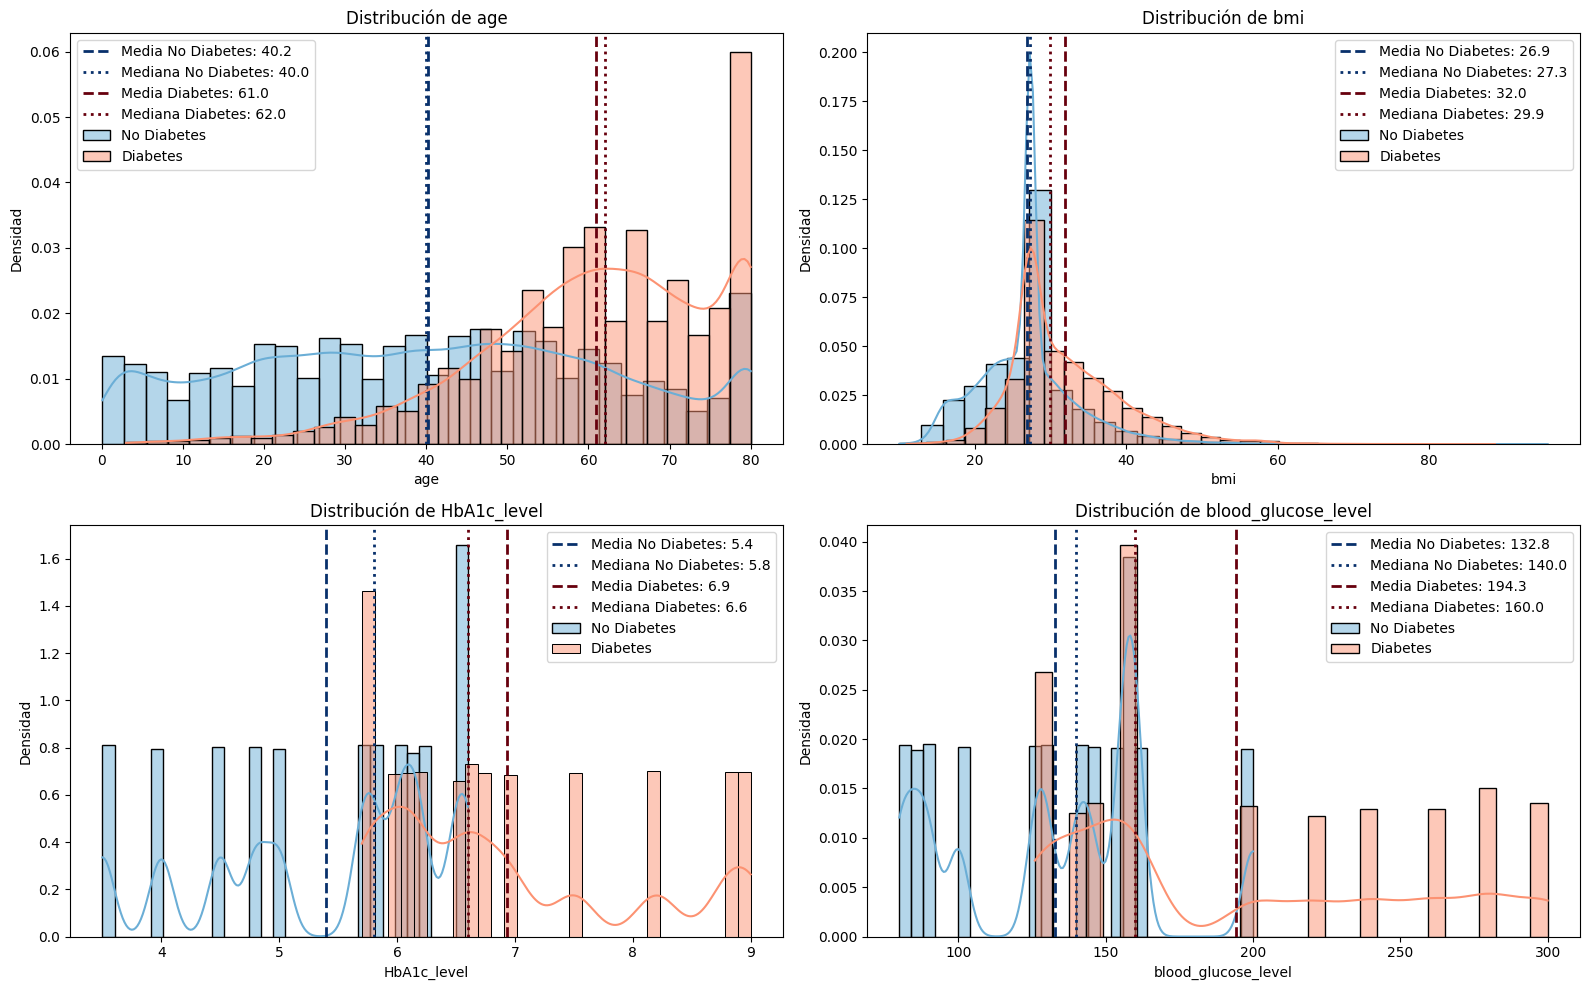

In [20]:
# Lista de variables numéricas
variables = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Crear grilla de subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Colores base y oscuros para líneas
colores = {
    0: ('#6baed6', '#08306b'),   # (azul claro, azul oscuro)
    1: ('#fc9272', '#67000d')    # (rojo claro, rojo oscuro)
}
clases = {0: 'No Diabetes', 1: 'Diabetes'}

# Recorrer variables
for i, var in enumerate(variables):
    ax = axes[i]
    handles = []

    for clase in [0, 1]:
        datos = cat_analisis[cat_analisis['diabetes'] == clase][var]
        color_barras, color_lineas = colores[clase]

        # Histograma con curva KDE
        sns.histplot(
            data=datos,
            kde=True,
            stat='density',
            bins=30,
            label=f'{clases[clase]}',
            color=color_barras,
            ax=ax,
            alpha=0.5
        )

        # Media y mediana
        media = datos.mean()
        mediana = datos.median()

        # Línea de la media
        linea_media = ax.axvline(media, color=color_lineas, linestyle='--', linewidth=2)
        handles.append(linea_media)
        # Línea de la mediana
        linea_mediana = ax.axvline(mediana, color=color_lineas, linestyle=':', linewidth=2)
        handles.append(linea_mediana)

        # Agregar entradas personalizadas a la leyenda
        linea_media.set_label(f"Media {clases[clase]}: {media:.1f}")
        linea_mediana.set_label(f"Mediana {clases[clase]}: {mediana:.1f}")

    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Densidad')
    ax.legend()

# Ajustar diseño
plt.tight_layout()
plt.show()

Perfil del paciente con mayor probabilidad de diabetes (según el dataset)


*  **Edad:**
Los pacientes con diabetes tienen en promedio 20 años más que los no diabéticos (≈61 vs ≈40 años).
La probabilidad aumenta notablemente a partir de los 50 años.
Además, se observa una gran concentración de pacientes con diabetes en el rango de los 80 años.

*   **Índice de Masa Corporal (IMC):**
El sobrepeso eleva el riesgo, pero la obesidad es el factor crítico:

    IMC normal → probabilidad < 5%

    Sobrepeso → ~8%

    Obesidad → ~18%


*   **HbA1c level (Hemoglobina glicosilada):** El mejor discriminador entre grupos:

    Muy alto → ~37% de probabilidad de diabetes

    Alto → ~16%

    Normal → < 5%


Un nivel muy alto multiplica por más de 7 la probabilidad respecto al valor normal.

*   **Blood glucose level (Glucemia):**

Valores >180 mg/dL se asocian fuertemente con la presencia de diabetes.

Ningún paciente con glucemia < 100 mg/dL en este dataset fue diabético como ya se mencionó.

*   **Factores de riesgo adicionales:**
Como ya se mencionó, se puede resumir de las variables categorícas lo siguiente:

Hipertensión: ~ 28% de probabilidad de diabetes (vs < 7% sin hipertensión).

Enfermedad cardíaca: ~ 32% (vs ~ 8% sin enfermedad).

Fumadores “ex” → mayor riesgo (~ 17%) que fumadores actuales o no fumadores.

Leve predominio masculino (9.7% vs 7.6% en mujeres).

El perfil más riesgoso en este dataset es un hombre mayor de 50 años, con obesidad, hemoglobina glicosilada muy alta, glucosa elevada (>180 mg/dL), hipertensión y antecedentes cardíacos. Este conjunto de factores multiplica de forma muy significativa la probabilidad de tener diabetes.

### Ahora arrancamos a modificar la base de datos para preparla para aplicarle modelos de clasificación

In [21]:
#Codificación de las variables categóricas
le_gender = LabelEncoder()
le_smoke = LabelEncoder()

dataset["gender"] = le_gender.fit_transform(dataset["gender"])
dataset["smoking_history"] = le_smoke.fit_transform(dataset["smoking_history"])

test_df["gender"] = le_gender.fit_transform(test_df["gender"])
test_df["smoking_history"] = le_smoke.fit_transform(test_df["smoking_history"])

In [22]:
test_df.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,1,53.0,0,0,4,31.99,4.5,126,NaN
1,82280,0,22.0,0,0,4,25.96,6.6,130,NaN
2,33216,0,37.0,0,0,4,22.24,6.2,126,NaN
3,94551,0,29.0,0,0,5,31.01,5.0,80,NaN
4,43760,1,30.0,0,0,2,28.66,6.6,100,NaN


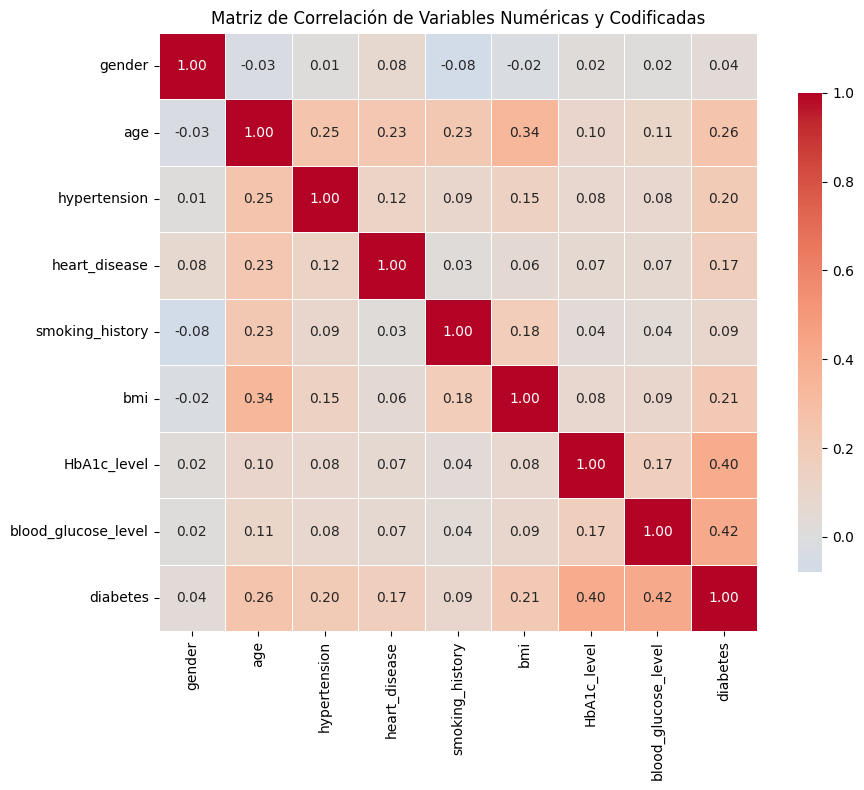

In [23]:
# 1. Crear copia sin la columna 'patient'
corr_df = dataset.drop(columns='patient')

# 2. Calcular matriz de correlación de Pearson
corr_matrix = corr_df.corr(numeric_only=True)

# 3. Visualizar con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,              # mostrar valores numéricos
    fmt=".2f",               # formato con 2 decimales
    cmap="coolwarm",         # colores de negativo a positivo
    center=0,                # centro de la escala de colores
    linewidths=0.5,          # líneas entre cuadros
    square=True,             # celdas cuadradas
    cbar_kws={"shrink": 0.8} # reducir barra de color
)
plt.title("Matriz de Correlación de Variables Numéricas y Codificadas")
plt.tight_layout()
plt.show()

En esta matriz de correlación se puede observar lo siguiente:
 - Si se analiza la columna o fila diabetes y se compara con las demás se puede concluir existe una correlación lineal positiva no tan fuerte entre la edad, la hipertensión, la enfermedad cardíaca y el nivel de masa corporal y el hecho de tener diabetes. Sí se observa una correlación lineal positiva más acentada y fuerte en los porcentajes de hemoglobina glicosilada y en el nivel de glucosa en sangre, siendo estas las variables mas correlacionadas a la variable objetivo 'diabetes'.
 - Otra observación que se puede realizar dejando de lado la variable diabetes, es que hay una correlación lineal positiva no muy fuerte entre la edad y el nivel de masa corporal, indicando que a mayor edad, se tiende a tener un mayor nivel de masa corporal, lo que indicaría que las personas se descuidan a mayor edad y tienden a tener mas grasa corporal.

In [24]:
# División entre features (X) y target (y)
X = dataset.drop(columns=["diabetes"])  # Elimina la columna target para dejar solo las features
y = dataset["diabetes"]

# división entre entrenamiento y evaluación (elegimos un 10% para test ya que es un dataset grande y preferimos tener más datos para entrenamiento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

Se realizó un preprocesamiento inicial para permitir el uso de algoritmos de clasificación. Las variables categóricas gender y smoking_history fueron transformadas a valores numéricos, asegurando consistencia en la codificación tanto para el dataset de entrenamiento como para el de prueba.
Posteriormente, se separó el conjunto de datos en variables predictoras (X) y variable objetivo (y), y se efectuó una división estratificada en un 90% para entrenamiento y un 10% para prueba.
En cuanto a la variable age, se detectaron valores extremadamente bajos (0.08 años), que podrían corresponder a errores de registro como ya se mencionó. Sin embargo, para no reducir el tamaño del conjunto de entrenamiento, se decidió conservar la totalidad de observaciones. El mismo criterio se aplicó para otros posibles valores atípicos en distintas variables.

## 4) Entrenamiento de modelo XGBoost con hiperparámetros por defecto

In [25]:

# Entrenamiento y evaluación del modelo base
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

# Predicciones sobre entrenamiento y test
y_pred_train = xgb_base.predict(X_train)
y_pred_test = xgb_base.predict(X_test)

# Matriz de confusión y reporte para entrenamiento
print("---------------------------------------------------------")
print("Matriz de confusión (entrenamiento):")
print(confusion_matrix(y_train, y_pred_train))
print("\nReporte de clasificación (entrenamiento):")
print(classification_report(y_train, y_pred_train))

# Matriz de confusión y reporte para test
print("---------------------------------------------------------")
print("Matriz de confusión (validación):")
print(confusion_matrix(y_test, y_pred_test))
print("\nReporte de clasificación (validación):")
print(classification_report(y_test, y_pred_test))

---------------------------------------------------------
Matriz de confusión (entrenamiento):
[[78155    67]
 [ 1962  5316]]

Reporte de clasificación (entrenamiento):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     78222
           1       0.99      0.73      0.84      7278

    accuracy                           0.98     85500
   macro avg       0.98      0.86      0.91     85500
weighted avg       0.98      0.98      0.97     85500

---------------------------------------------------------
Matriz de confusión (validación):
[[8670   26]
 [ 235  569]]

Reporte de clasificación (validación):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      8696
           1       0.96      0.71      0.81       804

    accuracy                           0.97      9500
   macro avg       0.96      0.85      0.90      9500
weighted avg       0.97      0.97      0.97      9500



c:\Users\Damaso Solinas\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:31:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Como nos interesa el recall en este caso de la clase diabetes = 1, ya que en la realidad se intentería prevenir equivocarse al detectar diabetes, intentamos generar un modelo que sea mas fuerte en esta métrica, ya que el modelo elegido con sus hiperparametros por defecto si bien arroja unas métricas sólidas como una precision alta para ambas clases y una accuracy tambien alta, el recall de la clase que interesa: pacientes con diabetes, no es lo suficientemente bueno, el modelo predice bastanes casos que realmente tienen diabetes como si no lo tuvieran y esto podría suponer un gran problema a la hora de diagnosticar en el caso que la decisión se tomara a partir de un modelo de aprendizaje automático.

## 5) Entrenamiento de modelo XGBoost con hiperparámetros optimizados por Optuna

En el siguiente modelo la métrica a optimizar en un principio era F1 Score pero el modelo todavía seguía arrojando un recall no lo suficientemente bueno, por lo que se optó optimizar F Beta Score, siendo Beta = 6, priorizando así un mejor recall que precision.

In [ ]:
# OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA PARA MAXIMIZAR RECALL


# Función objetivo
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),           # Nº de árboles
        'max_depth': trial.suggest_int('max_depth', 1, 50),                     # Profundidad máxima
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),       # Nº mínimo de muestras en un nodo para hacer un split.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),       # Tasa de aprendizaje
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),               # Porcentaje de datos por árbol
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),  # % de columnas por árbol
        'gamma': trial.suggest_float('gamma', 0.0, 100.0),                      # Umbral para split
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 100.0),              # Regularización L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 100.0),            # Regularización L2
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 200),  # Compensar desbalanceo
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)

    # Usamos cross-validation con recall como métrica
    score = cross_val_score(model, X_train, y_train,
                            scoring=make_scorer(fbeta_score, beta=6),
                            cv=5, n_jobs=-1)


    return np.mean(score)

# Ejecutar la búsqueda de hiperparámetros
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Probar 50 combinaciones


[I 2025-08-26 18:31:49,730] A new study created in memory with name: no-name-6bd32355-6f57-4ae3-a4da-d4e357354a75
[I 2025-08-26 18:31:54,293] Trial 0 finished with value: 0.9216137238722549 and parameters: {'n_estimators': 869, 'max_depth': 44, 'min_child_weight': 16, 'learning_rate': 0.10253251290770443, 'subsample': 0.9490760678009805, 'colsample_bytree': 0.29140439257241635, 'gamma': 44.5853590592722, 'reg_alpha': 57.49109140618581, 'reg_lambda': 46.39239706302991, 'scale_pos_weight': 136.65224337305645}. Best is trial 0 with value: 0.9216137238722549.
[I 2025-08-26 18:31:57,954] Trial 1 finished with value: 0.9292321925167218 and parameters: {'n_estimators': 751, 'max_depth': 46, 'min_child_weight': 27, 'learning_rate': 0.1187441722367523, 'subsample': 0.9391922252192577, 'colsample_bytree': 0.4798130835427511, 'gamma': 86.6904944344824, 'reg_alpha': 69.87799301413659, 'reg_lambda': 73.47223986734193, 'scale_pos_weight': 44.28627630408971}. Best is trial 1 with value: 0.92923219251

In [27]:
# Mostrar el mejor resultado
print("------------------------------------------------------")
print("Mejores hiperparámetros encontrados:")
print(study.best_params)

------------------------------------------------------
Mejores hiperparámetros encontrados:
{'n_estimators': 271, 'max_depth': 11, 'min_child_weight': 9, 'learning_rate': 0.2614136434816966, 'subsample': 0.49248442841382956, 'colsample_bytree': 0.21994783107323068, 'gamma': 7.547901670459655, 'reg_alpha': 99.03833815989789, 'reg_lambda': 35.66868178585231, 'scale_pos_weight': 34.50143926471152}


In [28]:
best_model = XGBClassifier(**study.best_params)
best_model.fit(X_train, y_train)

# Predicciones con el modelo optimizado
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("Matriz de confusión (entrenamiento, modelo optimizado):")
print(confusion_matrix(y_train, y_pred_train))
print("\nReporte de clasificación (entrenamiento):")
print(classification_report(y_train, y_pred_train))

print("---------------------------------------------------------")
print("Matriz de confusión (validación, modelo optimizado):")
print(confusion_matrix(y_test, y_pred_test))
print("\nReporte de clasificación (validación):")
print(classification_report(y_test, y_pred_test))

Matriz de confusión (entrenamiento, modelo optimizado):
[[62990 15232]
 [  113  7165]]

Reporte de clasificación (entrenamiento):
              precision    recall  f1-score   support

           0       1.00      0.81      0.89     78222
           1       0.32      0.98      0.48      7278

    accuracy                           0.82     85500
   macro avg       0.66      0.89      0.69     85500
weighted avg       0.94      0.82      0.86     85500

---------------------------------------------------------
Matriz de confusión (validación, modelo optimizado):
[[7059 1637]
 [  13  791]]

Reporte de clasificación (validación):
              precision    recall  f1-score   support

           0       1.00      0.81      0.90      8696
           1       0.33      0.98      0.49       804

    accuracy                           0.83      9500
   macro avg       0.66      0.90      0.69      9500
weighted avg       0.94      0.83      0.86      9500



Se observa como el modelo ha mejorado notablemente en la detección de pacientes que presentan diabetes dado las otras variables, si bien no tiene una precisión muy alta, (es decir ha predecido en muchos casos de clase positiva es decir pacientes que presentan diabetes pero que realmente no sufren de la enfermedad), es preferible perder precisión pero ganar en sensibilidad (recall) y detectar casi todos los pacientes que realmente tienen diabetes. Si bien han quedado 13 pacientes que el modelo los clasificó como que no tenian diabetes en la muestra de validación, pero realmente sí tenían, puede deberse a casos más excepcionales o a características que el modelo no ha tenido en cuenta. 

Un recordatorio de lo que significan las métricas más importantes:

 - Precision: de la cantidad de casos que clasificó el modelo de una clase, cuantos realmente pertenecen a dicha clase, en la muestra de validación para la clase 1 (pacientes que tienen diabetes) sería 791/(1637+791) = 0.33

 - Recall: de la cantidad de casos que realmente pertenecen a una clase, cuantos clasificó/ detectó el modelo correctamente, en la muestra de validación para la clase 0 (pacientes que no tienen diabetes) sería 7059/(7059+1637) = 0.81

 - F1 Score: media armónica entre precision y recall siende la misma = 2 x ((precision x recall) / precision + recall)

Sobre el overfitting/ sobreajuste: 

- Se observa que el modelo generaliza bien, obteniendo métricas sólidas para el conjunto de entrenamiento las cuales se repiten y son practicamente iguales en el conjunto de validación, por que no se estaría observando un sobreajuste por parte del modelo, no se aprendió de memoria la clasificación del conjunto de entrenamiento y es capaz de generalizar y clasificar en nuevas situaciones.

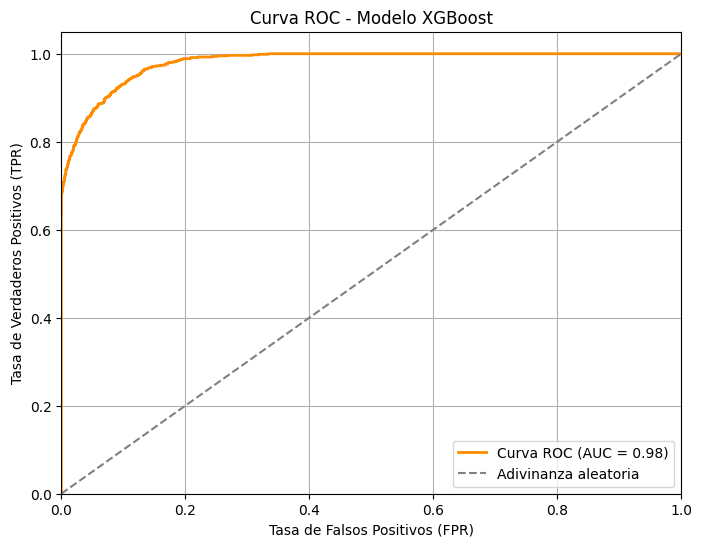

In [29]:
# 1. Obtener las probabilidades de clase positiva (1)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 3. Calcular AUC
roc_auc = roc_auc_score(y_test, y_proba)

# 4. Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {roc_auc:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Adivinanza aleatoria')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

En este gráfico de curva ROC se puede observar nuevamente como el modelo tiene métricas solidas de recall y funciona muy bien para detectar aquellos casos de diabetes. Tiene un alto porcentaje de verdaderos positivos y un bajo porcentaje de falsos positivos, lo que lleva a un área bajo la curva del 0,98. 

In [30]:
optuna.visualization.plot_optimization_history(study)

En el gráfico anterior se observa como el modelo fue aprendiendo en sus 50 iteraciones, indicando la línea continua roja, el historial de los mejores hiperparametros que fue encontrando que maximicen el valor objetivo que en este caso fue la métrica F Beta score.

In [31]:
optuna.visualization.plot_param_importances(study)

Aquí se observa la importancia de los hiperparametros en la construcción del modelo, siendo el más importante el hiperparametro encargado de balancear las clases desbalanceadas.

###  SHAP Values

C:\Users\Damaso Solinas\AppData\Local\Temp\ipykernel_5640\3720840997.py:8: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



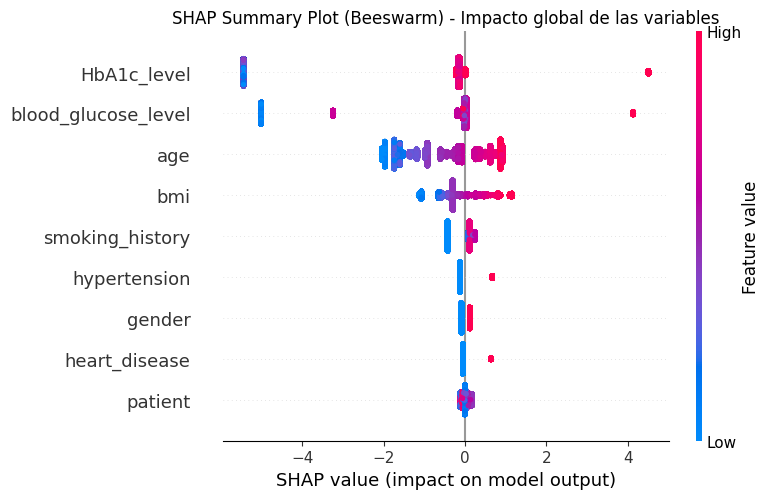

In [ ]:
#  Crear el explicador SHAP para el modelo XGBoost
explainer = shap.TreeExplainer(best_model)

#  Calcular los valores SHAP para el set de entrenamiento
shap_values = explainer.shap_values(X_train)

#  Gráfico resumen tipo beeswarm (impacto global de cada variable)
shap.summary_plot(shap_values, X_train, plot_type="dot", show=False)
plt.title("SHAP Summary Plot (Beeswarm) - Impacto global de las variables")
plt.tight_layout()
plt.show()



En el grafíco anterior se observa el impacto global de las variables en el modelo y como determinan/ construyen estas al modelo.
 - La lista de la izquierda son las variables que se eligieron para construir el modelo.
 - Cada observación representa un punto en el gráfico.
 - La barra vertical de la derecha indica el color para el valor de la variable explicativa, en este caso, las observaciones que presenten un valor bajo de la variable estarán marcadas con azul mientras que las que presenten un valor mayor, se irán marcando con un gradiente de color rojo.
 - La barra horizontal de abajo, SHAP Value es el valor SHAP para cada observación y variable correspondiente, indica cuantro contribuye dicha variable a aumentar o disminuir la predicción del modelo respecto al valor base, por lo que valores SHAP altos estarían indicando que dicha variable contribuye o aumenta la probabilidad de que el paciente tenga diabetes, mientras que valores SHAP bajos indicarían lo contrario.

Aclarado esto, se puede observar valores altos sobretodo de las variables hemoglobina glicosilada, nivel de glucosa en sangre, edad e índice de masa corporal, estarían aumentando la probabilidad o empujando la misma hacia una mayor posibilidad de que el paciente tenga diabetes. 

C:\Users\Damaso Solinas\AppData\Local\Temp\ipykernel_5640\3998400335.py:2: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



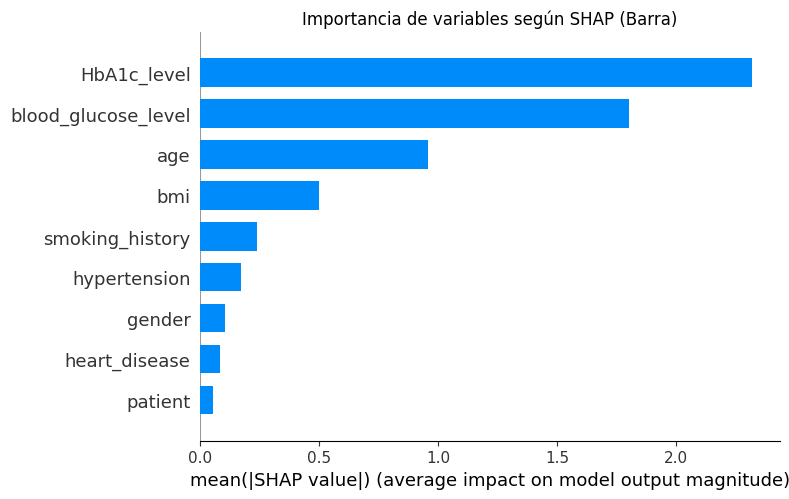

In [ ]:
#  Gráfico resumen tipo barras (importancia media absoluta)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Importancia de variables según SHAP (Barra)")
plt.tight_layout()
plt.show()



En este gráfico, se observa la media de los valores SHAP por variable explicativa, por lo tanto las variables que más contribuyen a determinar la clasificación del modelo. Las primeras 4 son las que mas pesan en este modelo y las mismas son las siguientes en orden de importancia:
 - Hemoglobina glicosilada
 - Nivel de glucosa en sangre
 - Edad
 - Nivel de masa corporal

c:\Users\Damaso Solinas\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning:

invalid value encountered in divide

c:\Users\Damaso Solinas\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning:

invalid value encountered in divide



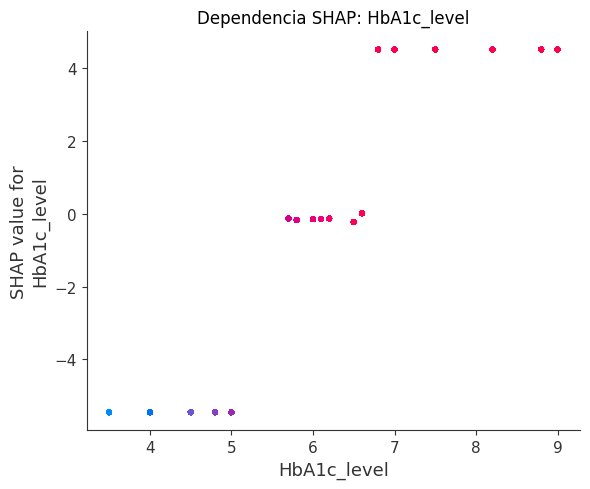

In [ ]:
#  Gráfico de dependencia para la variable más importante
importances = np.abs(shap_values).mean(axis=0)
top_feature = X_train.columns[np.argmax(importances)]
shap.dependence_plot(top_feature, shap_values, X_train, show=False)
plt.title(f"Dependencia SHAP: {top_feature}")
plt.tight_layout()
plt.show()



Aquí se puede complementar los gráficos anteriores y observar la correlación entre los valores SHAP para la variable Hemoglobina glicosilada y los niveles de la misma variable, donde se analiza que valores bajos de la variable indican valores SHAP pequeños para dicha variable y hay un correlación positiva entre las mismas. 

Cabe aclarar que esto es un análisis a mayor profundidad de las variables que pesan en el modelo y de como contribuyen en la clasificación y a determinar la probabilidad de clasificación por parte del mismo. 

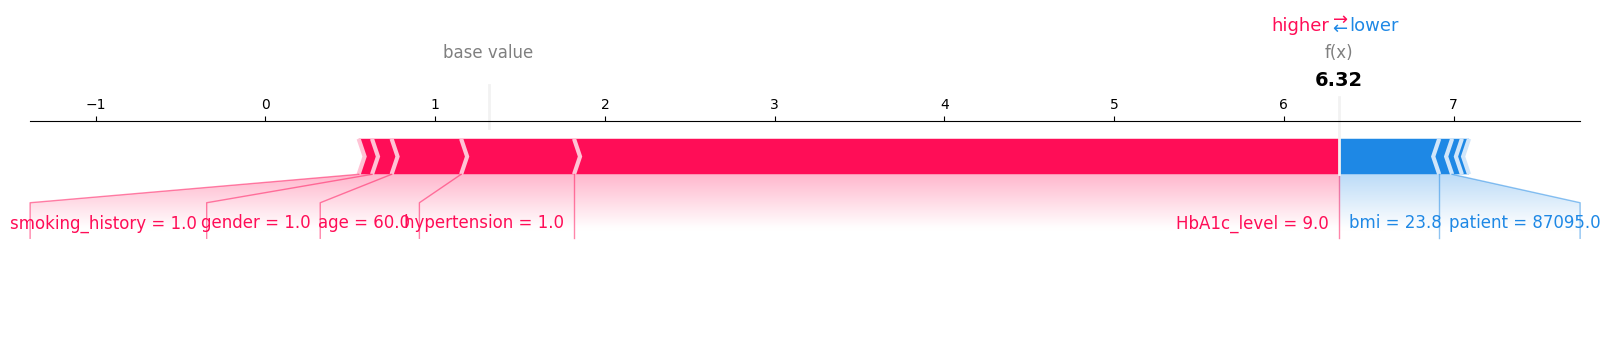

Fila seleccionada en X_train: 83209
Número de paciente: 87095
Probabilidad de diabetes para observación elegida: 1.00
Clase PREDICHA para observación elegida: 1
Clase REAL para observación elegida: 1


In [45]:
#------------------------------------------------------------------------------------------
# Selecciona una observación fija (semilla reproducible)
np.random.seed(10)
idx = np.random.randint(0, X_train.shape[0])

# Muestra el force plot para esa observación con título
shap.initjs()  # 
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx], 
    X_train.iloc[idx],
    matplotlib=True  # O quita este parámetro para la versión interactiva en Jupyter
)

# idx es el índice de la observación
proba = best_model.predict_proba(X_train.iloc[[idx]])[0, 1]
clase_predicha = best_model.predict(X_train.iloc[[idx]])[0]

# Obtener la clase real (target) y el número de paciente
clase_real = y_train.iloc[idx]
paciente_nro = X_train.iloc[idx]["patient"]  # si la columna se llama 'patient'

print(f"Fila seleccionada en X_train: {idx}")
print(f"Número de paciente: {paciente_nro:.0f}")
print(f"Probabilidad de diabetes para observación elegida: {proba:.2f}")
print(f"Clase PREDICHA para observación elegida: {clase_predicha}")
print(f"Clase REAL para observación elegida: {clase_real}")

En este gráfico "Force Plot" se observa como para una determinada observación, el valor de f(x) es la predicción del modelo para dicha observación en escala log-odds, es el resultado de sumar el base value más el aporte de cada variable con sus SHAP valores. Aquí se puede analizar como cada variable contribuye positiva o negativamente al resultado de f(x), teniendo el mayor peso la variable Hemoglobina glicosilada.

- Los valores que se indican al lado de cada variable, no es valor de SHAP, si no, el valor que asume dicha variable en la observación analizada.

- El f(x) es la salida del modelo antes de aplicar la función sigmoide y el valor de su probabilidad es aplicarle la función sigmoide a dicha función y se observan para diferentes valores de f(x) las probabilidades arrojadas por el modelo.

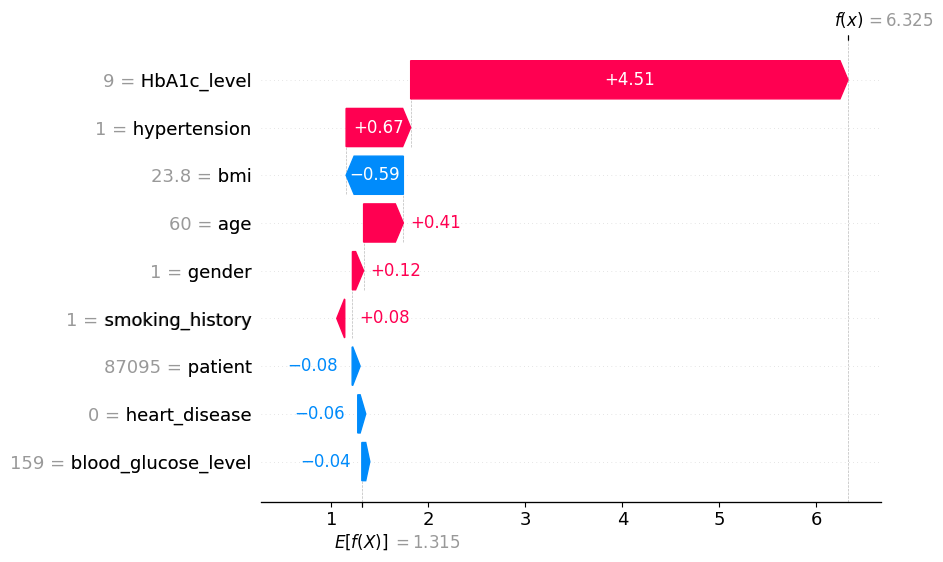

In [ ]:
# El mismo análisis pero en gráfico de Waterfall
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_train.iloc[idx],
    feature_names=X_train.columns
))

Aquí se complementa el análisis anterior. El E[f(x)] (también llamado base value en SHAP) es el valor esperado de la predicción del modelo antes de ver ninguna característica del paciente. Es decir que es la predicción promedio del modelo (en log-odds), antes de sumar los aportes de cada variable.

### Features Importance (Importancia de las variables)

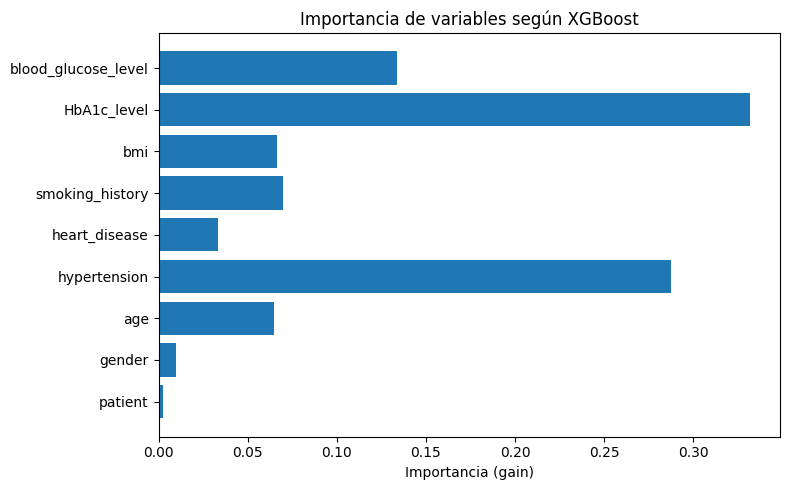

In [48]:
#  Importancia de variables según XGBoost (gain)
importances_xgb = best_model.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(X_train.columns, importances_xgb)
plt.xlabel("Importancia (gain)")
plt.title("Importancia de variables según XGBoost")
plt.tight_layout()
plt.show()


Importancia XGBoost (gain):

- Este gráfico indica cuánto mejora (en promedio) la función objetivo cada variable cuando se usa para hacer un split en los árboles del modelo.
- Es una medida interna del modelo basada en cómo cada variable mejora la predicción al construir los árboles.
- No indica si el aporte es positivo o negativo, solo cuánto “ayuda” a separar clases.
- No explica predicciones individuales, solo la importancia global.

A diferencia del análisis de los valores SHAP, se observa que las variables que tienen mayor ganancia o que mejoran la función objetivo y son mas imporantes/ útiles al hacer splits en los arboles de decisión son: Hemoglobina glicosilada, Hipertensión (variable que no era determinante en SHAP Values) y el nivel de glucosa en sangre.


La diferencia de este análisis con el de los valores SHAP es que los mismos: 
- Explican cómo y cuánto cada variable contribuye a la predicción de cada observación (local y global).
- Permiten ver si una variable aumenta o disminuye la probabilidad para cada caso.
- Son aditivos: la suma de los SHAP values + base value da la predicción para cada individuo.

### Conclusión

Se podría elegir las primeras 4 variables ya mencionadas en el análisis de SHAP Values (Hemoglobina glicosilada, Nivel de glucosa en sangre, Edad, Nivel de masa corporal) y construir el mismo modelo a partir de allí para observar si el mismo mejora y es capaz de generalizar mejor, ya que las otras variables no elegidas, podrían estar afectando negativamente al modelo al ser mas prescindibles y estar tal vez empeorando el modelo elegido con todas las variables. Aunque como se observó después en el análisis de la Importancia de las Variables del modelo XGBoosting, las mas importantes y útiles para hacer splits entre los arboles y construir el modelo participó una variable (Hipertensión) que en SHAP Values no era determinante, al igual que Edad que tenía un valor alto de SHAP pero en el último estudio, no contribuía demasiado a mejorar el modelo en sus arboles de decisión.

# 6) Se usa el modelo para clasificar la muestra de testeo

In [34]:
# Elimina columnas
test_df = test_df.drop(columns=["diabetes"])

In [35]:
# Predice
predicciones_test = best_model.predict(test_df)

predicciones_test

array([0, 0, 0, ..., 1, 0, 0], shape=(5000,))

In [36]:
#submission = pd.DataFrame({
    #"patient": test_df["patient"],
    #"diabetes": predicciones_test
#})

#submission.to_csv("sample_submission.csv", index=False)
#submission